# Probabilistic Dirichlet search algorithm

In [1]:
import os
import io
import random
import copy
import torch
import json
import pickle
import contextlib
import numpy as np
from operator import itemgetter
from ultralytics import YOLO 
from mylib import myutils
from mylib import simsettings
from mylib import simtools
from mylib import yolo_patch_softmax
from mylib import probtools
from constants import OBS_SCALE, CELL_SIDE, MAP_RESOLUTION, DISPLAY_STEP
from constants import AGENT_HEIGHT, AGENT_RADIUS 
from constants import MAX_ITER, CONFIDENCE_THRESHOLD
from constants import NUM_CLASSES, DIRICHLET_PRIOR
from dotenv import load_dotenv
load_dotenv()

import habitat_sim
import habitat_sim.nav as nav
from habitat.utils.visualizations import maps
from habitat_sim.utils import common as utils

# Reload imported modules
%load_ext autoreload
%autoreload 2

# Load YOLO model
yolo_model = YOLO("yolo11x.pt")

# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
with contextlib.redirect_stdout(io.StringIO()):
    yolo_model = yolo_model.to(device)

In [2]:
# Load the JSON file for simulation
with open('simulation-data/simulations.json', 'r') as f:
    simulations = json.load(f)

# Simulation configuration 
simulation = simulations[5]
 
# Access its fields
SCENE = simulation["scene"]
TARGET_OBJECT = simulation["target_object"]
TARGET_OBJECT_ID = simulation["target_object_id"]
REAL_TARGET_LOCATION = simulation["target_object_location"]

# Load the JSON file for RGB camera intrinsics
with open('simulation-data/camera-intrinsics.json', 'r') as f:
    intrinsics = json.load(f)

# Load bins per class
with open('simulation-data/object-classes-bins.json', 'r') as f:
    classes_bins = json.load(f)

# Load indoor objects
with open('simulation-data/indoor-objects.json', 'r') as f:
    data = json.load(f)
    indoor_objects = [list(item.values())[0] for item in data["indoor_classes"]]

# Load Dirichlet priors
with open('simulation-data/dirichlet-alpha-priors-augmented.pkl', 'rb') as f:
    dirichlet_priors = pickle.load(f)

# Simulator configuration
dataset_config_file = os.path.join(os.getenv("AI2THOR_DATA"), "ai2thor-hab.scene_dataset_config.json")
sim_settings = {
    "seed": 1,
    "dataset": dataset_config_file,  # Scene dataset
    "scene": SCENE,  # Scene path
    "width": 1024,  # Spatial resolution of the observations
    "height": int(1024*OBS_SCALE),
    "default_agent": 0,
    "sensor_height": AGENT_HEIGHT,  # Height of sensors in meters
    "color_sensor": True,  # RGB sensor
    "depth_sensor": True,  # Depth sensor
    "enable_physics": False,  # kinematics only
}
# Initialize the simulator
cfg = simsettings.make_cfg(sim_settings)
sim = habitat_sim.Simulator(cfg)

Renderer: NVIDIA GeForce GTX 1060 6GB/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 535.230.02


[14:54:57:452272]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'ai2thor-hab' : Lighting Layout Attributes '/home/joaocbranco/projects/habitat-meta/ai2thor-hab/ai2thor-hab/configs/scenes/RoboTHOR/FloorPlan_Train5_2.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
MeshTools::compile(): ignoring Trade::MeshAttribute::TextureCoordinates 1 as its binding slot is already occupied by Trade::MeshAttribute::TextureCoordinates 0
[14:54:57:629111]:[Warning]:[Sim] Simulator.cpp(595)::instanceStageForSceneAttributes : The active scene does not contain semantic annotations : activeSemanticSceneID_ = 0
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flippin

Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


arning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 3 pixels
Trade::BasisImporter::openData(): missing orientation metadata, assuming Y down. Set the assumeYUp option to suppress this warning.
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the result will be shifted by 2 pixels
Trade::BasisImporter::image2D(): Y-flipping a compressed image that's not whole blocks, the r

In [3]:
# Get the root node of the active scene graph
scene_root = sim.get_active_scene_graph().get_root_node()
scene_bb = scene_root.cumulative_bb
scene_dims = scene_bb.size()
scene_height = scene_dims[1]  # Height of the scene

# Define navmesh settings
navmesh_settings = habitat_sim.NavMeshSettings()
navmesh_settings.agent_height = AGENT_HEIGHT
navmesh_settings.agent_radius = AGENT_RADIUS
navmesh_settings.agent_max_climb = 0.2
navmesh_settings.agent_max_slope = 45.0
navmesh_settings.include_static_objects = True  # Include static objects in the navmesh computation

# Recompute the navmesh for the current scene
sim.recompute_navmesh(sim.pathfinder, navmesh_settings)

# Generate the topdown map --> 1 cm per pixel
topdown_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=MAP_RESOLUTION, draw_border=True)
topdown_map = myutils.map_to_rgb(topdown_map)
topdown_map = myutils.add_axis_to_map(topdown_map)
topdown_map = myutils.retain_largest_white_chunk(topdown_map)
topdown_resolution = topdown_map.shape[:2]

# Generate the grid map --> 30 cm per pixel (robot has radius 15 cm)
grid_map = maps.get_topdown_map(sim.pathfinder, height=0, meters_per_pixel=CELL_SIDE, draw_border=False)
grid_map = myutils.map_to_rgb(grid_map)
grid_map = myutils.retain_largest_white_chunk(grid_map)
grid_resolution = grid_map.shape[:2]

# Free positions
grid_free_cells, map_free_cells, world_free_coords = [], [], []

# Occupied positions
grid_occ_cells, map_occ_cells, world_occ_coords = [], [], []

# Compute free and occupied
for grid_x in range(grid_resolution[0]):
    for grid_y in range(grid_resolution[1]):
        # Convert grid coordinates to real world coordinates and then to top-down map coordinates
        real_world_z, real_world_x = maps.from_grid(grid_x, grid_y, grid_resolution, pathfinder=sim.pathfinder)
        map_x, map_y = maps.to_grid(real_world_z, real_world_x, topdown_resolution, pathfinder=sim.pathfinder)

        if sim.pathfinder.is_navigable([real_world_x, 0.0, real_world_z]) and topdown_map[map_x, map_y, 0] == 255 and grid_map[grid_x, grid_y, 0] == 255:
            world_free_coords.append([real_world_x, 0.0, real_world_z])
            map_free_cells.append([map_x, map_y])
            grid_free_cells.append([grid_x, grid_y])
        else:
            world_occ_coords.append([real_world_x, 0.0, real_world_z])
            map_occ_cells.append([map_x, map_y])
            grid_occ_cells.append([grid_x, grid_y])
            grid_map[grid_x, grid_y, :] = [128, 128, 128]  # Grey out non-navigable

# Merge free and occupied positions into a single list
grid_cells = grid_free_cells + grid_occ_cells
map_cells = map_free_cells + map_occ_cells
world_coords = world_free_coords + world_occ_coords

# Count the number of occupiable positions
num_free_cells = len(grid_free_cells)
print(f"Number of free cells: {num_free_cells}")

Number of free cells: 187


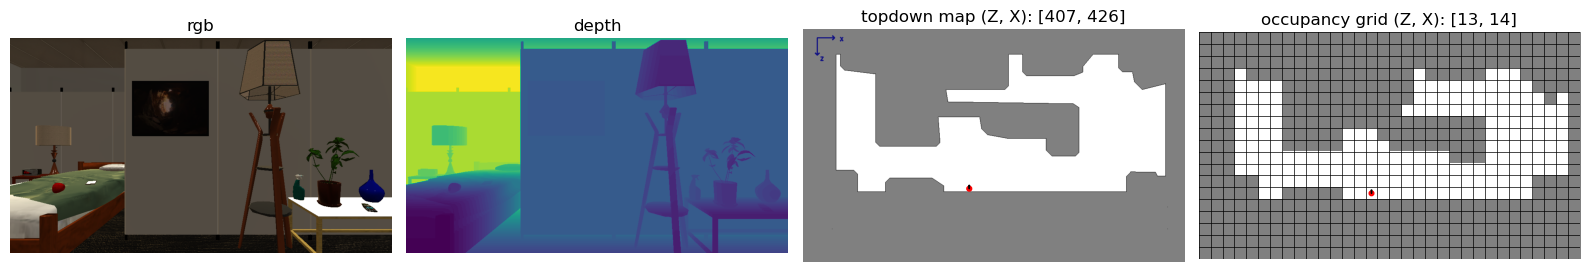

In [4]:
# Initialize belief map: NUM_CLASSES + 1 for the background 
belief_map = [[np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR for _ in range(grid_resolution[1])] for _ in range(grid_resolution[0])]

# Compute maximum possible entropy per cell
MAX_ENTROPY = probtools.compute_entropy(np.ones(NUM_CLASSES + 1) * DIRICHLET_PRIOR)

# Initialize an agent
agent = sim.initialize_agent(sim_settings["default_agent"])

# Sample a random position (within the possible ones)
grid_position = random.choice(grid_free_cells)
idx = grid_free_cells.index(grid_position)
world_position = world_free_coords[idx]
map_position = map_free_cells[idx]

# Sample a random yaw rotation
agent_yaw = random.choice([0, 90, 180, 270])
agent_quart = myutils.yaw_to_quaternion(agent_yaw)

# Set agent state
agent_state = habitat_sim.AgentState()
agent_state.position = world_position
agent_state.rotation = agent_quart
agent.set_state(agent_state)

# Compute agent radius in both maps
min_bounds, max_bounds = sim.pathfinder.get_bounds()
x_dim = max_bounds[0] - min_bounds[0]
topdown_radius = (AGENT_RADIUS / x_dim * topdown_resolution[0])
grid_radius = (AGENT_RADIUS / x_dim * grid_resolution[0])

# Get initial agent position tuple and radius tuple
agent_radius = (topdown_radius, grid_radius)
agent_positions = (map_position, grid_position)

# Get initial observations and maps
observations = sim.get_sensor_observations(0)
rgb = observations["color_sensor"]
depth = observations["depth_sensor"]

# Display the initial simulation state (maps + observations)
simtools.display_sim_state(rgb, depth, topdown_map, grid_map, agent_positions, agent_radius, agent_yaw)

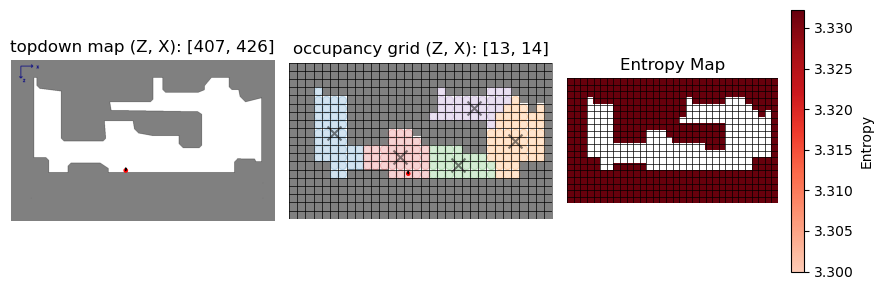

Cluster Centers: [[8, 5], [9, 27], [12, 20], [11, 13], [5, 22]]
Distances: [14, 17, 7, 3, 20]
Avg Entropies: [3.3322045073751982, 3.3322045073752022, 3.332204507375202, 3.3322045073752005, 3.332204507375201]
Avg Target Probs: [0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571]
Moving to cluster center: [11, 13] with path length: 3
Path: [[12, 14], [11, 14], [11, 13]]
Normalized Entropies: [          1           1           1           1           1]
Normalized Distances: [        0.7        0.85        0.35        0.15           1]
Scores: [    0.59714     0.55214     0.70214     0.76214     0.50714]


-->Likelihood vector:
 [ 5.9372e+92  1.7859e-51 4.2128e-218  5.5528e-23  4.8486e+23  1.6197e+11  8.6586e+51  3.1774e+14  1.1662e+87  3.5805e-36  4.3136e+75 3.4603e+173   5.278e-37  9.6927e+22           0 5.4458e-273 9.9095e-255    0.000743           0 3.4383e-150 4.0129e-100  1.3774e+75           0  1.3385e+28           0  9.6016e-87


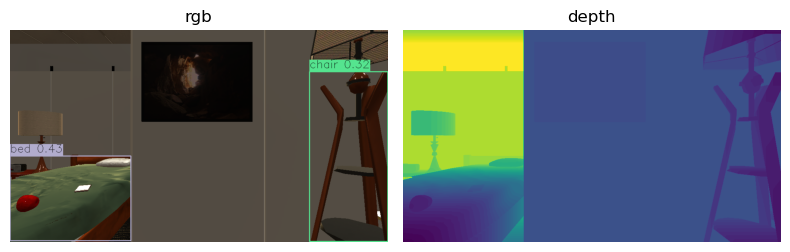

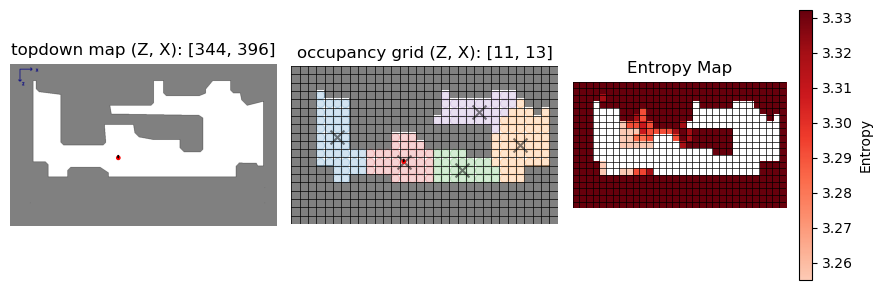



-->Likelihood vector:
 [ 3.0268e+92  1.1349e-44 1.4263e-205  9.7395e-23  1.2999e+24  8.2097e+12  1.1725e+52  9.9317e+17  3.1671e+84  2.2305e-52   7.293e+70 3.3439e+173  1.2136e+23  2.1461e+24           0 4.7309e-267 5.8361e-171      56.555           0 2.3311e-143 6.8243e-104  5.0955e+75           0  1.6552e+29           0  2.9976e-67
 4.7826e-321]
Max likelihood:
 3.34390255656253e+173

Likelihood vector: [ 9.0518e-82  3.394e-218           0 2.9126e-196 3.8874e-150 2.4551e-161 3.5064e-122 2.9701e-156  9.4713e-90 6.6704e-226  2.181e-103           1 3.6292e-151 6.4178e-150           0           0           0 1.6913e-172           0 6.9713e-317 2.0408e-277  1.5238e-98           0 4.9498e-145           0 8.9644e-241
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [6.8844e-108 1.0104e-294  5.9237e-97  9.3046e-21   1.896e-52 1.6411e-142  3.8678e-52 3.4252e-108 7.4175e+113 2.5542e-184  6.7095e+42 1.0684e-156  3.8818e+13      6.1237           0 8.3857e-149  2.449e-120 4.0848e-130 

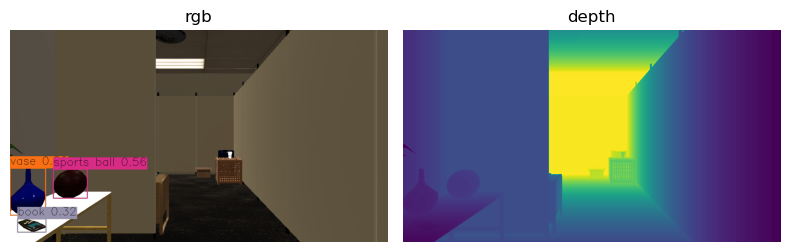

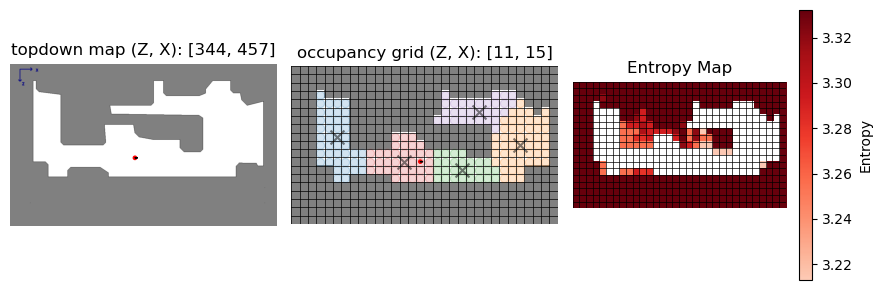



-->Likelihood vector:
 [ 4.2766e+17 7.1521e-301  4.8672e-93  2.6608e-94  4.7442e+33  6.8888e+20  3.1793e+21      4.2495  1.1507e+45  1.2908e-38   3.383e+50 9.1347e-151  9.8987e+63  3.7053e+40 1.0268e-277  2.6217e-83  5.9669e-08 2.7452e-115 1.7708e-180 5.0054e-220  3.5194e-57  2.8825e+85           0 8.7297e-292           0   6.747e-45
           0]
Max likelihood:
 2.8824873344676977e+85

Likelihood vector: [ 1.4837e-68           0 1.6886e-178  9.231e-180  1.6459e-52  2.3899e-65   1.103e-64  1.4743e-85   3.992e-41  4.478e-124  1.1736e-35  3.169e-236  3.4341e-22  1.2854e-45           0 9.0953e-169  2.0701e-93 9.5236e-201 6.1432e-266 1.7365e-305  1.221e-142           1           0           0           0 2.3407e-130
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 3.7886e-48           0  5.1122e-85 7.4273e-141  6.2269e-15  3.7055e-86  1.0375e-18 8.2568e-102  2.4506e+77 4.7497e-206  7.6446e+42 2.6086e-100  1.4566e+57  7.9743e-65 1.6368e-181  8.6553e+12   2.749e-20 9.4554e-157

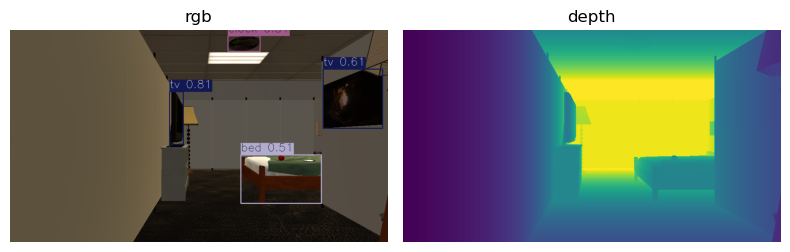

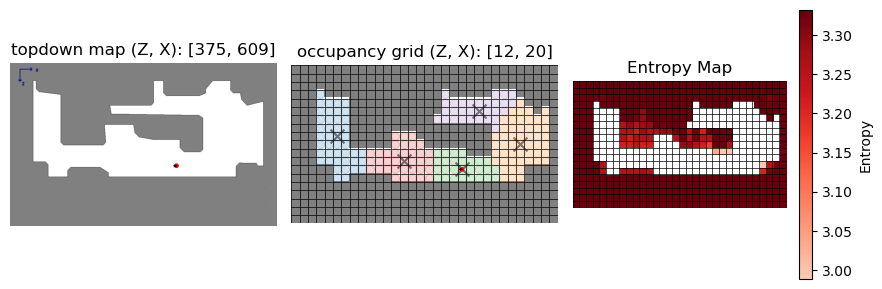



-->Likelihood vector:
 [9.6654e-118 3.3977e-254 1.5401e-131  1.6538e-63  3.8179e-33  1.4745e-86  6.3363e-45 2.8679e-175  8.0902e+84 2.6951e-217  7.6166e+35           0  5.4937e+11   9.995e-23           0 1.9308e-168 6.3818e-143  6.471e-158           0           0  7.3681e-46  2.7573e+16           0           0           0 1.2712e+176
 8.6366e-278]
Max likelihood:
 1.271247251461282e+176

Likelihood vector: [7.6031e-294           0 1.2115e-307 1.3009e-239 3.0032e-209 1.1599e-262 4.9843e-221           0   6.364e-92           0 5.9914e-141           0 4.3215e-165 7.8624e-199           0           0 5.0202e-319           0           0           0 5.7959e-222 2.1689e-160           0           0           0           1
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 4.3967e+88   1.128e-25 2.0315e-175 2.2308e-110   3.181e+28  8.3551e+18  8.8115e+18  2.2966e+13  9.7665e+78  2.1136e-30  2.0209e+71 2.8551e+173  6.6898e+25  1.6247e+24           0 2.0956e-192 1.0222e-142  6.5841e+12

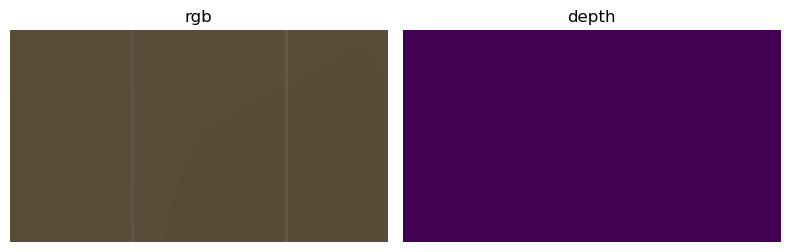

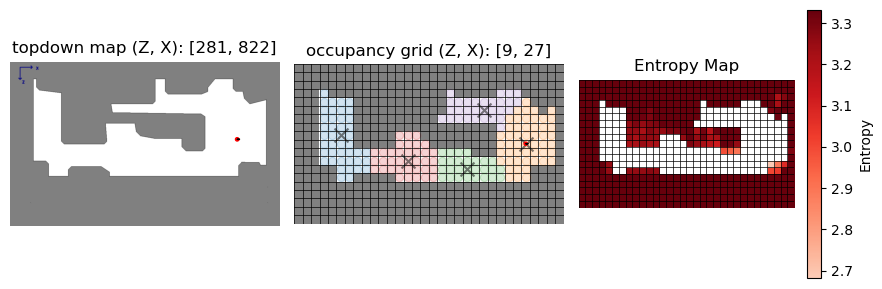



-->Likelihood vector:
 [ 3.0712e+77  1.2537e-21  9.1371e-82 7.4197e+166  5.1899e+46  2.1914e+29  2.7796e+16  4.3079e+64  4.4674e+72  1.9157e-30    1.29e+67  2.205e-174  9.6421e+15  1.9184e+33           0 1.2178e-159  5.6661e-67  7.1232e+15 6.2185e-223   7.38e-243 2.2509e-150  1.0615e+83           0  1.8428e+51           0  2.3619e-23
  4.536e-289]
Max likelihood:
 7.419655288772631e+166

Likelihood vector: [ 4.1392e-90 1.6898e-188 1.2315e-248           1 6.9948e-121 2.9535e-138 3.7463e-151 5.8061e-103  6.0211e-95 2.5819e-197 1.7387e-100           0 1.2995e-151 2.5856e-134           0           0 7.6367e-234 9.6005e-152           0           0 3.0337e-317  1.4306e-84           0 2.4837e-116           0 3.1833e-190
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [3.4199e-102           0  1.1384e-16 1.0743e+130  1.3496e+05  5.0679e-57      3.4996  8.9045e-67  2.7027e+76 3.0995e-204  9.6295e+42 3.6657e-151  6.0179e+07  9.3415e-93 3.5601e-245   1.176e-32  2.1792e-47 1.4474e-133

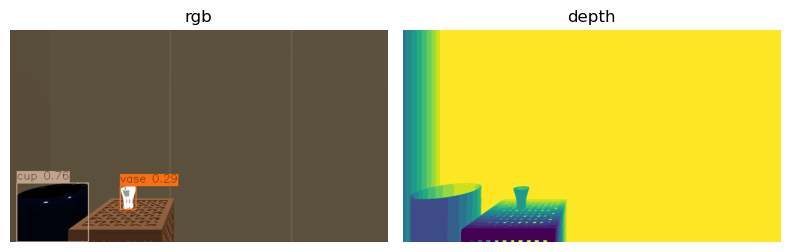

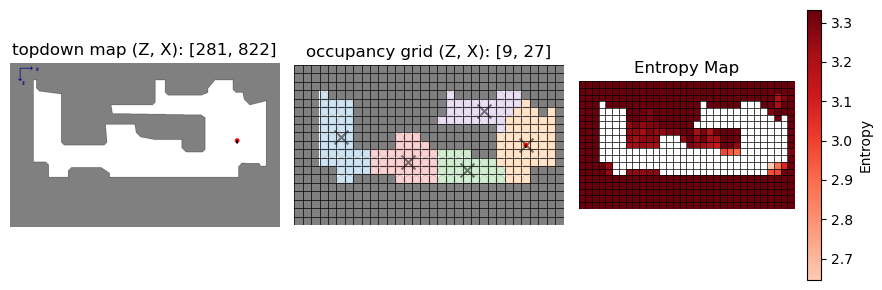



-->Likelihood vector:
 [1.1374e-138           0  1.554e-294 6.5383e-163 8.0302e-119 1.8079e-103 3.6502e-117 1.2663e-171  2.2916e+93 6.2182e-183  3.3898e+66 1.4404e-251  6.0723e+40  9.354e-108           0 7.9722e+163  2.7479e-13 6.8205e-192 2.1019e-194 2.1727e-103  1.6205e+37  2.4118e+43           0           0           0  1.8182e-45
 4.1664e-138]
Max likelihood:
 7.972207170680389e+163

Likelihood vector: [1.4267e-302           0           0           0 1.0073e-282 2.2677e-267 4.5787e-281           0  2.8745e-71           0   4.252e-98           0 7.6169e-124 1.1733e-271           0           1 3.4469e-177           0           0 2.7253e-267 2.0327e-127 3.0253e-121           0           0           0 2.2807e-209
 5.2262e-302]
Max likelihood: 1.0


-->Likelihood vector:
 [ 1.2496e-98           0 3.8399e-252 4.6436e-137  1.3596e-52 1.5825e-157   7.271e-82 7.7062e-284 8.5935e+103 1.8511e-286  9.3313e+32 1.6047e-315  2.4086e+24  3.1762e-34           0 1.7353e-238 1.3388e-176 2.9889e-203

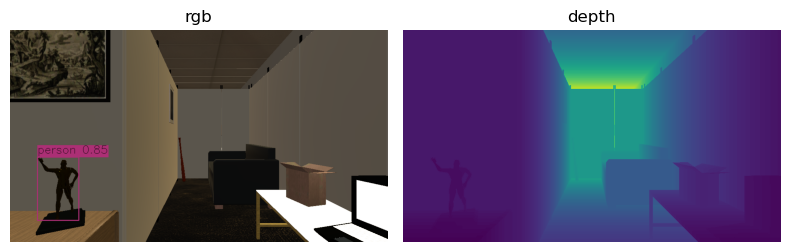

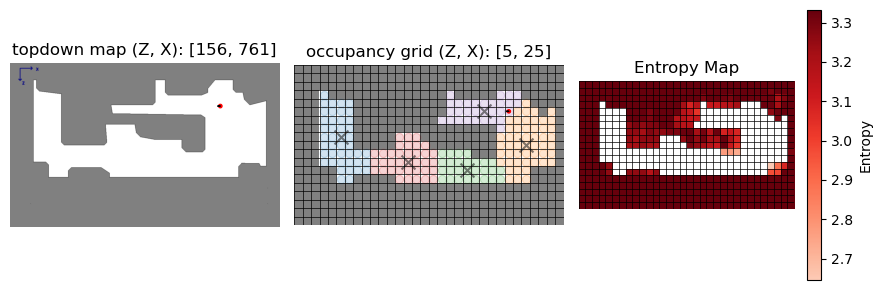



-->Likelihood vector:
 [ 6.3646e-33           0 1.0422e-197 6.2321e-141  1.6975e+17  2.4232e-28   1.919e-45 1.7359e-203  2.1598e+64 9.7703e-196  2.4492e+33           0  7.8212e+28      165.03           0 2.7861e-171 1.1757e-195 1.4319e-210           0           0   5.697e-46  1.6262e+24           0           0           0 7.4548e-111
           0]
Max likelihood:
 2.1597743244072405e+64

Likelihood vector: [ 2.9469e-97           0 4.8254e-262 2.8855e-205  7.8596e-48   1.122e-92 8.8851e-110 8.0372e-268           1 4.5238e-260   1.134e-31           0  3.6213e-36  7.6411e-63           0   1.29e-235 5.4437e-260 6.6297e-275           0           0 2.6378e-110  7.5295e-41           0           0           0 3.4516e-175
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 2.2399e-24           0 8.2719e-265 4.0096e-213  1.8625e-72 6.3488e-100  1.3719e-58 1.6351e-128  1.6082e+73 4.2323e-138   3.398e+61  2.771e-251  1.0421e+54  2.1432e-22 1.4262e-294  6.3118e-32  9.2371e-31 1.7937e-240

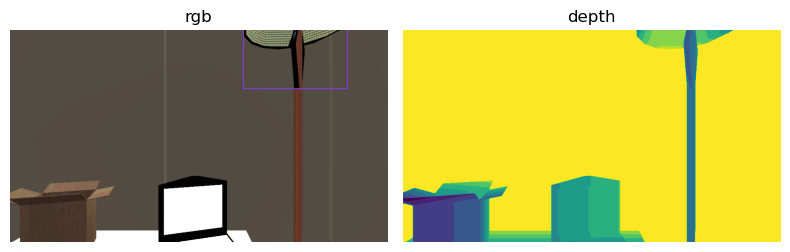

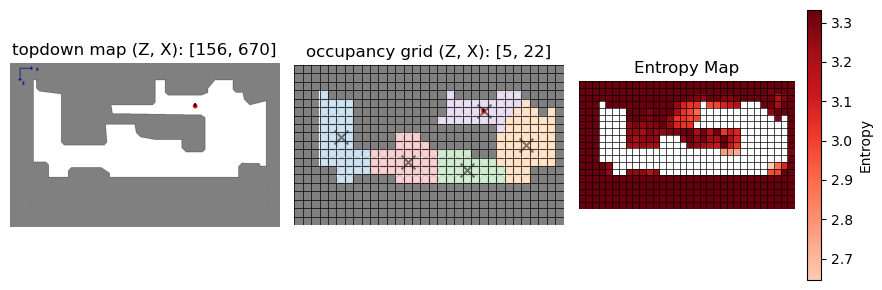



-->Likelihood vector:
 [ 9.4928e+87  1.1783e-92    0.013603  1.0993e-44  2.8235e+53   7.063e+64  9.2693e+59  2.8341e-53   1.807e+59 5.7445e+176  4.3829e+97 9.4668e-291  8.3833e-26  8.0276e+29           0 3.0423e-268 6.9643e-174      1.5642 7.8808e-269  2.527e-156 1.5282e-146  1.0967e+76           0  3.5109e+29           0 3.1879e-184
           0]
Max likelihood:
 5.744459175993004e+176

Likelihood vector: [ 1.6525e-89 2.0513e-269 2.3679e-179 1.9136e-221 4.9152e-124 1.2295e-112 1.6136e-117 4.9337e-230 3.1457e-118           1  7.6298e-80           0 1.4594e-202 1.3975e-147           0           0           0  2.723e-177           0           0 2.4703e-323 1.9091e-101           0 6.1119e-148           0           0
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 2.1035e+74  4.1709e-82  1.2967e-18   4.197e-27  6.6088e+64  5.3493e+76  4.7453e+31   1.956e+60  1.1127e+72  1.3925e+05  4.7124e+73 3.2037e-210  2.7166e+25 1.6302e+158           0  1.975e-116 4.5457e-153  3.1725e+06

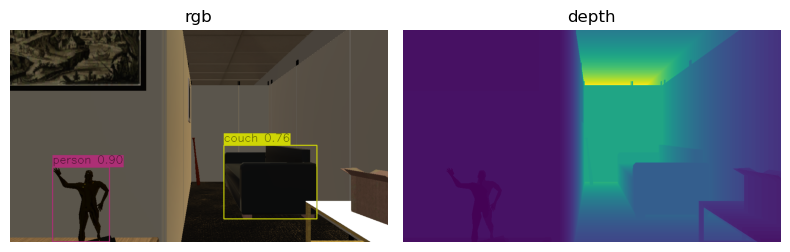

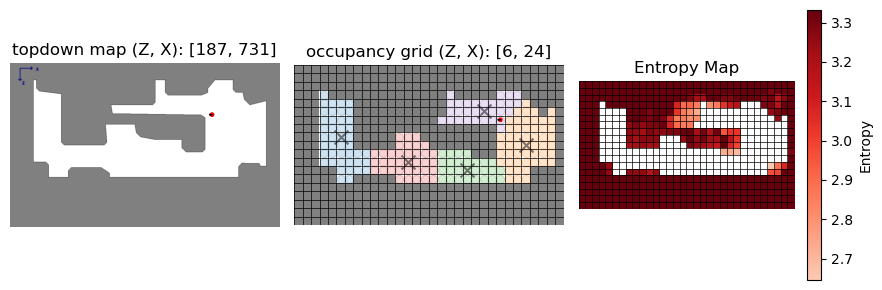



-->Likelihood vector:
 [ 1.1645e-26  5.4243e-59 4.0833e-209 5.3334e-123  2.1465e+32  1.3184e+43  8.9601e+09   4.907e-62  5.0744e+51 1.3149e-120  2.3228e+42           0  2.7911e+30  9.1262e+34           0 3.1569e-210 2.1673e-100 1.8537e-200 1.8626e-288 5.5941e-306  2.383e-168  1.1113e+68           0   9.783e+35           0 1.2685e-213
 2.4629e-291]
Max likelihood:
 1.1113341424814202e+68

Likelihood vector: [ 1.0479e-94 4.8809e-127 3.6742e-277 4.7991e-191  1.9315e-36  1.1863e-25  8.0625e-59 4.4154e-130   4.566e-17 1.1832e-188  2.0901e-26           0  2.5114e-38  8.2119e-34           0 2.8406e-278 1.9502e-168  1.668e-268           0           0 2.1443e-236           1           0  8.8029e-33           0 1.1414e-281
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 1.4745e+82 1.0324e-112 4.6479e-119   2.248e-72  2.4965e+36  1.7777e+62  7.3357e+23  6.9604e+58  1.1802e+71  2.7443e+25 3.8044e+156 2.0046e-205  8.5661e+58  4.2672e+39           0  3.8328e-52 8.7676e-179   2.799e+28

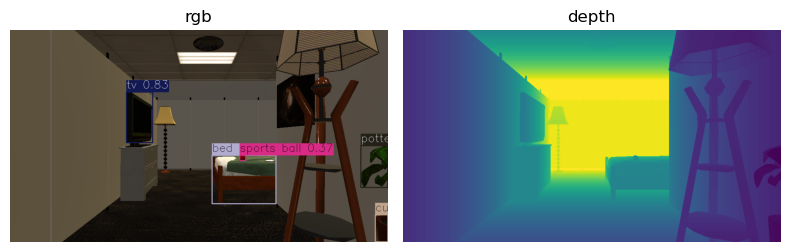

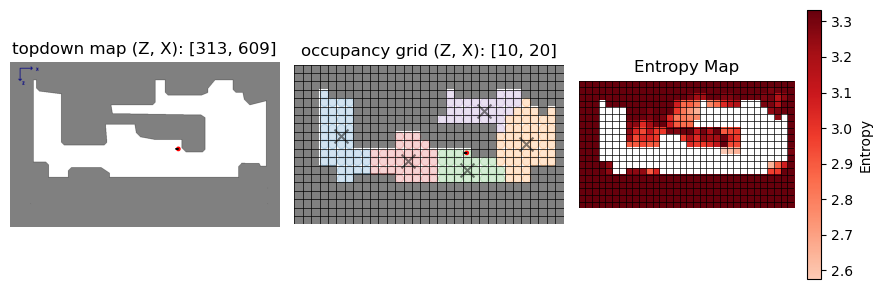



-->Likelihood vector:
 [ 1.0527e-73           0  1.487e-232 2.4655e-171  6.7184e-26  8.0481e-32  1.6911e-94 5.9984e-162  1.5366e+82 3.4069e-189  1.9002e+52           0  3.8036e+43  1.6127e+33           0 1.2723e+179 5.1872e-102 1.2615e-182           0 8.0693e-293   1.283e-34 2.9621e+100           0           0           0 4.4264e-109
           0]
Max likelihood:
 1.2723458671440323e+179

Likelihood vector: [8.2736e-253           0           0           0 5.2804e-205 6.3254e-211 1.3291e-273           0  1.2077e-97           0 1.4934e-127           0 2.9895e-136 1.2675e-146           0           1 4.0769e-281           0           0           0 1.0084e-213  2.3281e-79           0           0           0 3.4789e-288
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [  2.527e+81 2.9245e-103 2.3122e-283 1.7532e-175  2.3806e+32  1.7128e+23  2.8147e-21  4.7798e+08  5.3867e+59  6.1369e-37 2.7384e+116 5.5164e-260 1.9371e+153  4.5926e+91           0 3.4485e-160 2.0653e-113  1.9771e+2

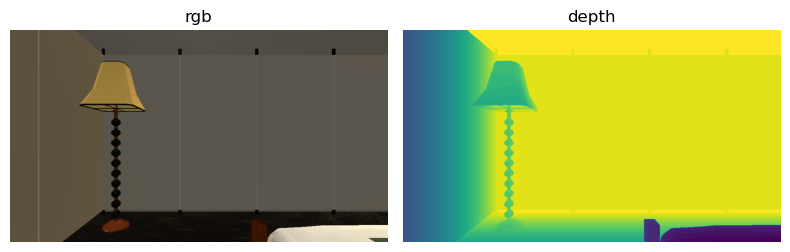

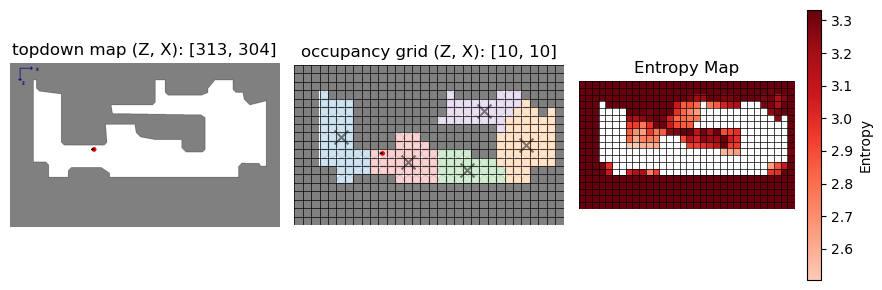



-->Likelihood vector:
 [ 4.1641e+72 1.1783e-107  8.4103e-83  2.8268e-61   1.841e+65  4.5472e+57  2.0342e+31  2.2903e+30  9.3865e+80 4.9362e+103  2.6986e+87   2.718e-46  9.795e+162  7.5344e+13           0 1.8491e-126 1.4964e-147  2.3213e+24  4.0977e+32  6.9796e-44  8.5012e-98  1.9148e+88  1.4323e+68  5.2564e+54           0      5.8813
 3.3002e-167]
Max likelihood:
 9.794989847858088e+162

Likelihood vector: [ 4.2513e-91  1.203e-270 8.5863e-246 2.8859e-224  1.8795e-98 4.6424e-106 2.0768e-132 2.3383e-133  9.5829e-83  5.0395e-60  2.7551e-76 2.7749e-209           1 7.6921e-150           0 1.8878e-289 1.5277e-310 2.3699e-139 4.1835e-131 7.1257e-207 8.6791e-261  1.9549e-75  1.4623e-95 5.3664e-109           0 6.0044e-163
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 4.4162e+71 5.4644e-112  4.2906e-80  1.8103e-64    1.83e+67  2.4993e+57  9.0477e+31  6.8642e+22  5.2273e+82 4.0187e+106  3.5779e+79   3.988e-47 5.6476e+164  5.0066e+11           0 5.5482e-138 2.3068e-166   2.289e+21

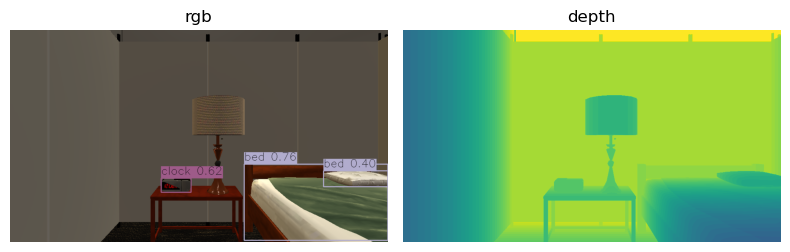

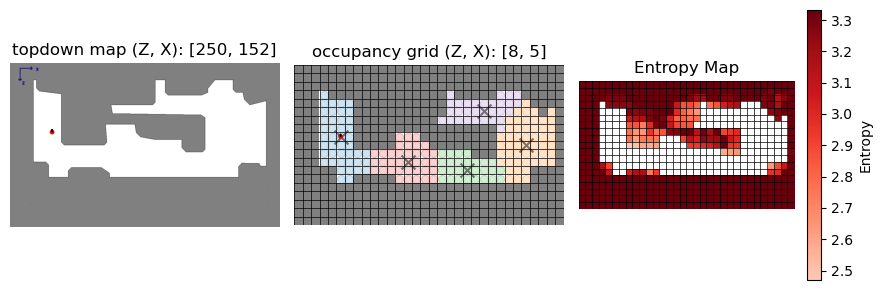



-->Likelihood vector:
 [ 1.6221e-28  7.5774e-48 2.1498e-231 2.0435e-104  1.3092e+07  4.6832e+39  1.0052e-24  4.0367e-07  1.4647e+59   6.431e-96  3.4859e+64           0  5.0077e+54  6.0108e+48           0 1.8087e+169  2.0208e+14 2.9271e-146 3.3744e-148  8.7946e-85  2.0113e-35  3.9265e+86           0  4.4927e+65           0 3.4292e-153
           0]
Max likelihood:
 1.8086938232660756e+169

Likelihood vector: [8.9685e-198 4.1894e-217           0 1.1298e-273 7.2383e-163 2.5893e-130 5.5579e-194 2.2318e-176 8.0979e-111 3.5556e-265 1.9273e-105           0 2.7687e-115 3.3233e-121           0           1 1.1173e-155 1.6184e-315 1.8656e-317 4.8624e-254  1.112e-204  2.1709e-83           0  2.484e-104           0 1.8774e-322
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 2.3184e-69           0 3.6795e-258 1.1111e-107  1.1274e-46  3.0121e-38  1.0263e-51 8.6974e-105  2.5629e+73 5.0775e-107  8.7225e+75 8.7367e-238  3.1603e+57   3.229e+10           0 5.2582e+154  1.4163e-15  2.2192e-9

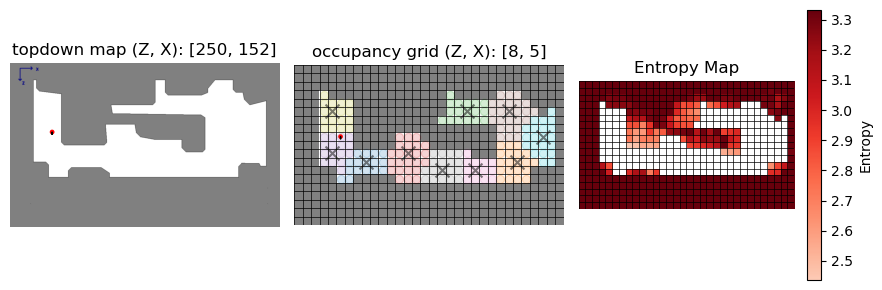

Cluster Centers: [[11, 8], [11, 26], [5, 20], [10, 13], [10, 4], [5, 25], [12, 21], [12, 17], [5, 4], [8, 29]]
Distances: [6, 24, 32, 10, 3, 29, 20, 16, 4, 30]
Avg Entropies: [3.1373606024731258, 3.275590750349986, 3.16701143326899, 3.1422392413737246, 3.3115110322418384, 3.2842299564133066, 3.2443497148545624, 3.300006252556468, 3.2896618008075613, 3.320050430105774]
Avg Target Probs: [0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.06547616262317889, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571, 0.03571428571428571]
Moving to cluster center: [10, 4] with path length: 3
Path: [[8, 4], [9, 4], [10, 4]]
Normalized Entropies: [    0.94153     0.98301     0.95043     0.94299     0.99379      0.9856     0.97363     0.99034     0.98723     0.99635]
Normalized Distances: [     0.1875        0.75           1      0.3125     0.09375     0.90625       0.625         0.5       0.125      0.9375]
Scores: [    0.72166     0

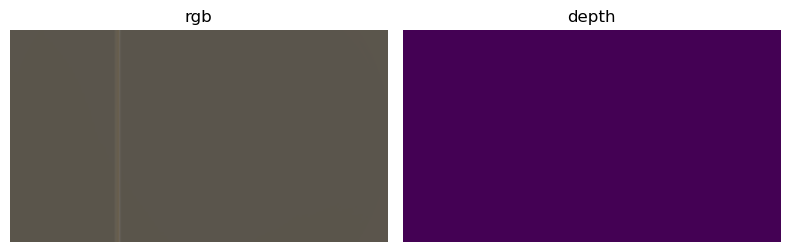

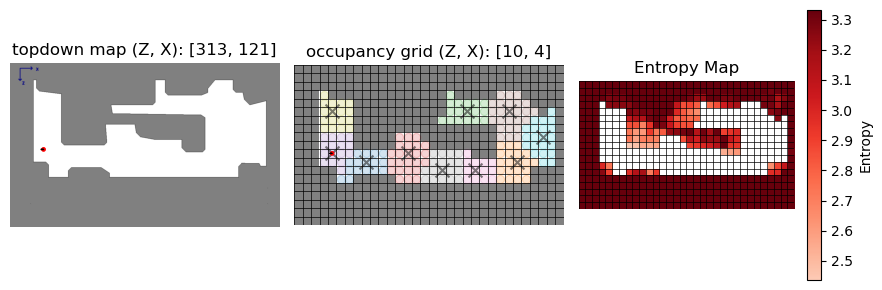



-->Likelihood vector:
 [ 4.3569e+69  5.3976e-89  9.5131e-79  8.6435e-56  1.5085e+62  3.8432e+60  4.0676e+32  8.7442e+32  9.8646e+83 3.1215e+103  1.2033e+91 1.8611e-264 9.1429e+158  1.5397e+16           0  1.4876e-89 5.0937e-102  6.5517e+26  3.6184e+35  1.7516e-26  1.8167e-60  9.3081e+87 1.2313e-215  1.6074e+53           0     0.54527
 7.8537e-298]
Max likelihood:
 9.142901191530605e+158

Likelihood vector: [ 4.7653e-90 5.9035e-248 1.0405e-237 9.4538e-215    1.65e-97  4.2035e-99 4.4489e-127 9.5639e-127  1.0789e-75  3.4141e-56  1.3161e-68           0           1 1.6841e-143           0  1.627e-248 5.5712e-261 7.1659e-133 3.9576e-124 1.9158e-185  1.987e-219  1.0181e-71           0  1.758e-106           0 5.9639e-160
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 3.0826e+74  3.8354e-97  8.3444e-80  1.1026e-49   5.227e+56  2.6699e+55  3.5027e+27  1.3581e+32  3.2802e+79 2.4735e+107  9.8468e+91 1.2586e-201 3.0138e+158  1.5643e+33           0  8.3767e-82  6.9724e-90   3.313e+26

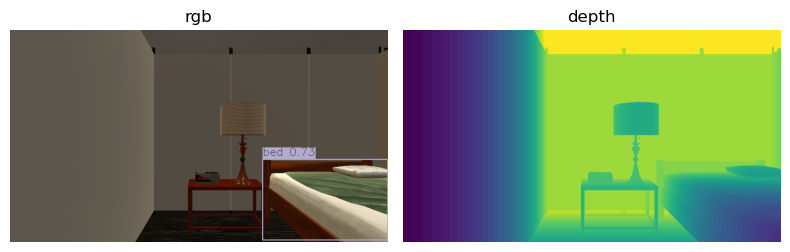

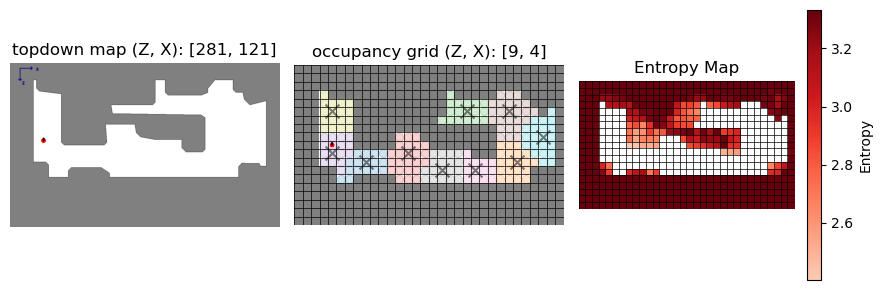



-->Likelihood vector:
 [ 2.7001e+72   2.744e-71  2.2998e-62  5.5682e-38  2.3125e+57  5.0556e+61  9.2598e+34  6.7883e+42  2.0588e+79  6.7065e+98  8.9717e+92 1.2406e-205 1.0125e+143  1.2977e+46 6.6856e-272  1.4495e-47  1.8877e-53  7.3031e+35  3.1868e+40  6.1691e-12  3.2473e-24  9.1735e+67 1.3544e-131  1.7392e+64 3.0687e-276 5.0995e-126
 1.0563e-265]
Max likelihood:
 1.0125110759465544e+143

Likelihood vector: [ 2.6668e-71 2.7101e-214 2.2714e-205 5.4994e-181  2.2839e-86  4.9931e-82 9.1454e-109 6.7044e-101  2.0333e-64  6.6237e-45  8.8609e-51           0           1  1.2817e-97           0 1.4316e-190 1.8644e-196 7.2128e-108 3.1475e-103 6.0928e-155 3.2072e-167  9.0601e-76 1.3377e-274  1.7177e-79           0 5.0365e-269
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 1.0073e+83 9.4145e-119 2.6522e-284   2.051e-35  5.9105e+51  2.8478e+35   1.003e+14    0.048392  2.0128e+44   4.549e+44   3.129e+93           0  8.7239e+79 1.7382e+104           0 2.5362e-201   1.636e-84  2.6927e+0

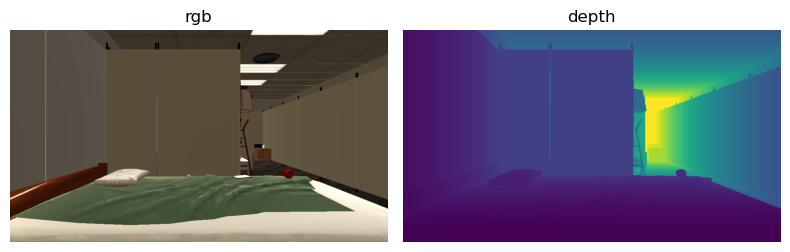

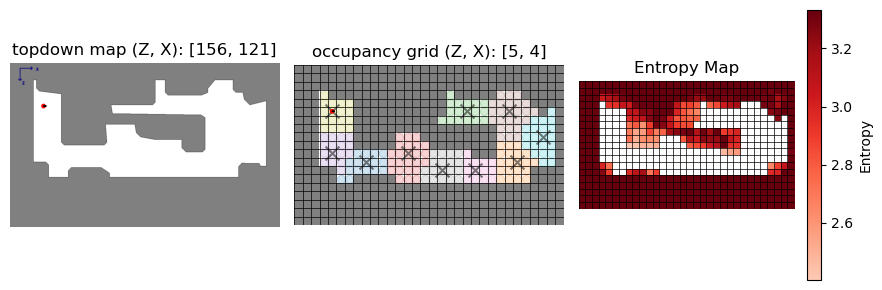



-->Likelihood vector:
 [  7.719e+73  3.5105e-62 2.3759e-304  2.2536e-33  1.9912e+12  1.5822e+42  1.4998e+20  5.1175e+15  9.0475e+88  1.9394e-57  1.4591e+84 3.4605e-317  8.8389e+50  4.0653e+22           0  1.289e+182   4.163e-33  3.7029e+34 4.1243e-208  3.7551e-26  2.2247e-86  4.0453e+89           0  7.3412e+59           0  8.747e-186
           0]
Max likelihood:
 1.2889989990273402e+182

Likelihood vector: [5.9884e-109 2.7234e-244           0 1.7483e-215 1.5448e-170 1.2275e-140 1.1636e-162 3.9701e-167  7.0191e-94 1.5045e-239   1.132e-98           0 6.8572e-132 3.1539e-160           0           1 3.2296e-215 2.8727e-148           0 2.9132e-208 1.7259e-268  3.1383e-93           0 5.6953e-123           0           0
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 3.7603e-05           0 5.5808e-222 3.5906e-154       40879  2.0552e-37  1.9897e-66 3.6865e-128  3.6814e+54  1.8715e-14 1.4145e+124           0 6.2594e+149  3.6491e+79           0 8.0762e-102 1.8664e-118 1.5111e-14

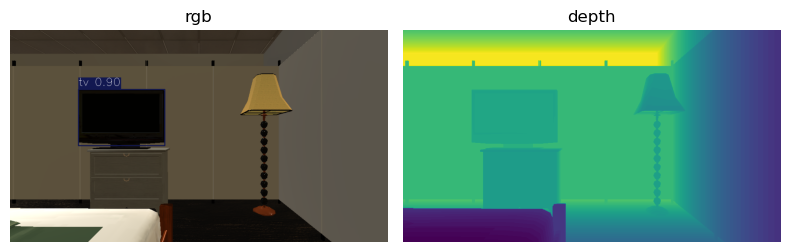

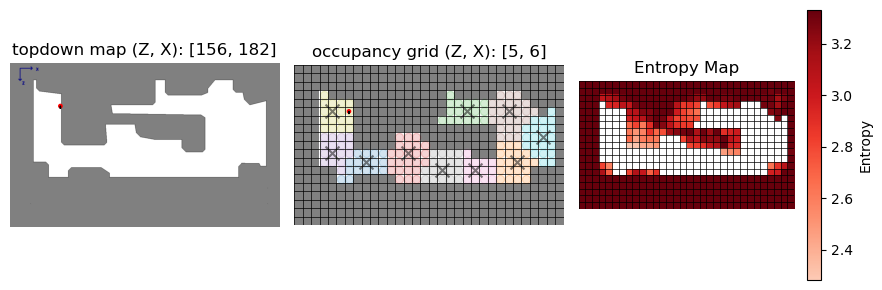



-->Likelihood vector:
 [ 3.3197e+72  1.1158e-63  7.0895e-77  2.0133e-33  4.7143e+12  4.4008e+69  1.0896e+20  6.3515e+13  5.4014e+88  1.4036e-59  9.1007e+83 1.2692e-215      7.6142  1.0448e+21           0  1.536e+183  8.0282e-86  1.1746e+33  2.0399e+64  3.1101e-25  3.626e-195  1.2284e+88 1.0423e-317  4.5144e+57 9.6739e-304 1.2039e-140
           0]
Max likelihood:
 1.535990281933986e+183

Likelihood vector: [2.1613e-111 7.2645e-247 4.6156e-260 1.3108e-216 3.0692e-171 2.8652e-114 7.0941e-164 4.1351e-170  3.5166e-95 9.1384e-243  5.925e-100           0 4.9572e-183 6.8021e-163           0           1 5.2267e-269 7.6471e-151 1.3281e-119 2.0248e-208           0  7.9974e-96           0 2.9391e-126           0 9.8813e-324
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 2.2019e+72  1.3042e-54  5.0002e-67  1.1072e-25  8.9663e+36  1.7904e+65  9.9122e+20  9.9891e+63 5.2017e+103  1.1361e+98  7.7214e+79 3.4132e-190      266.57  5.8093e+21           0 7.1687e+174  1.0862e-43  6.0483e+32

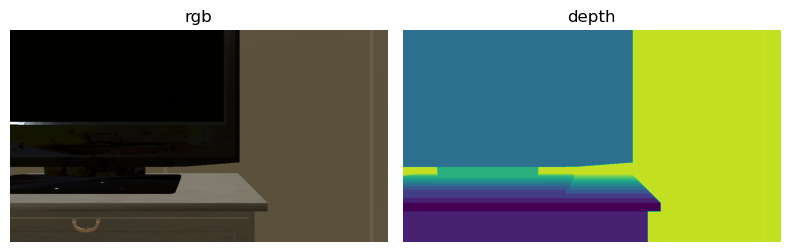

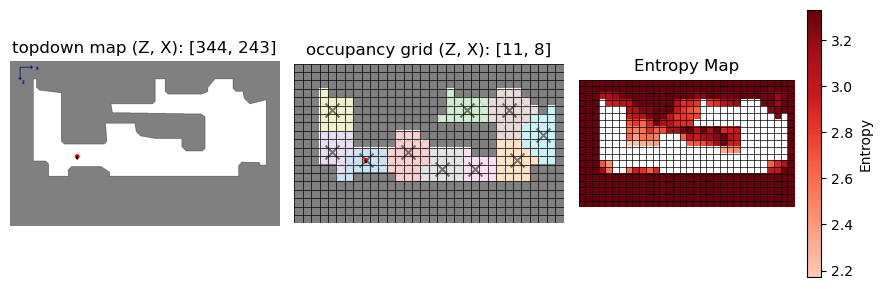

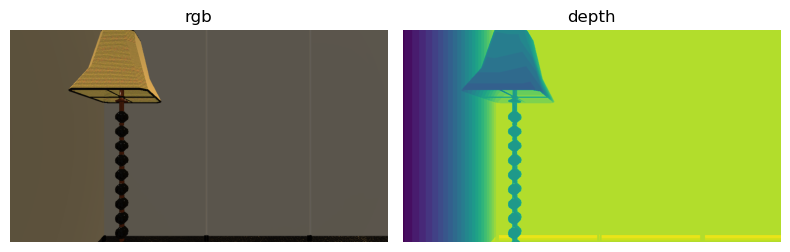

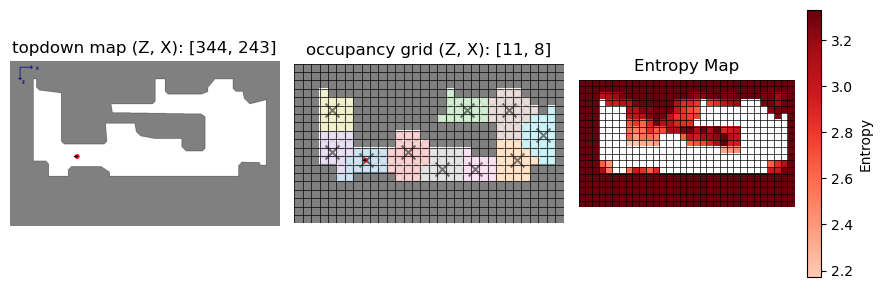



-->Likelihood vector:
 [  1.126e+74 1.3036e-101  1.9311e-76  1.6618e-62  5.4258e+67  6.1236e+59  3.9476e+32 5.3621e+103  3.6569e+82  2.525e+101 3.5549e+105  2.5228e-42 1.8263e+163  1.1691e+09           0  3.2306e+17  1.7882e-13  2.4058e+26  4.8072e+33  5.4181e+37   6.171e-33  9.0263e+87  1.8578e+64  3.9791e+52           0       17765
 1.9566e-140]
Max likelihood:
 1.826302182188637e+163

Likelihood vector: [ 6.1653e-90 7.1379e-265 1.0574e-239  9.099e-226  2.9709e-96  3.353e-104 2.1615e-131   2.936e-60  2.0023e-81  1.3826e-62  1.9465e-58 1.3814e-205           1 6.4015e-155           0 1.7689e-146 9.7916e-177 1.3173e-137 2.6322e-130 2.9667e-126 3.3789e-196  4.9424e-76  1.0172e-99 2.1788e-111           0 9.7273e-160
 1.0714e-303]
Max likelihood: 1.0


-->Likelihood vector:
 [ 1.6355e+23  8.4905e-18 5.3619e-161  4.6913e-59  6.8734e+25  2.9704e+35   0.0062887      87.799  4.8626e+44     0.50593  1.7783e+95 4.8281e-173 1.4648e+108  9.9304e+78           0  4.4673e+05  9.1266e-15   1.93e-116

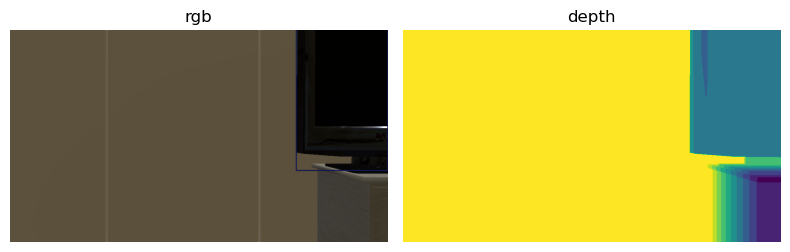

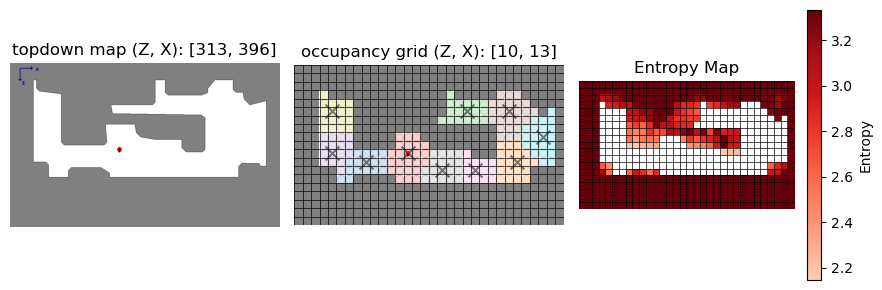



-->Likelihood vector:
 [  9.512e+71  2.6411e-49  8.9335e-46  3.3791e-06  2.8747e+43  4.7358e+58  1.5259e+31  3.2531e+62  1.8257e+90  9.8026e+97  2.0973e+71 1.4175e-158  2.1735e+09      29.357           0 2.2267e+160   1.281e+09  8.7686e+36  2.8994e+68  1.7067e+55      272.25 2.7175e+100 7.5446e-242  2.6477e+76 3.7076e-199 1.6664e-124
           0]
Max likelihood:
 2.2267364234301864e+160

Likelihood vector: [ 4.2717e-89 1.1861e-209 4.0119e-206 1.5175e-166  1.291e-117 2.1268e-102 6.8525e-130  1.4609e-98   8.199e-71  4.4022e-63  9.4189e-90 6.3658e-319  9.761e-152 1.3184e-159           0           1  5.753e-152 3.9379e-124  1.3021e-92 7.6647e-106 1.2227e-158  1.2204e-60           0  1.1891e-84           0 7.4837e-285
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 8.8816e+73  7.5989e-75  1.0465e-59  2.4882e-31   6.079e+53  2.3317e+57  6.0107e+30  1.3101e+46  1.9469e+78 1.0212e+102  1.1038e+95 1.9746e-207 7.8551e+143  2.9329e+64           0  1.9037e-71  5.6263e-58  3.6142e+2

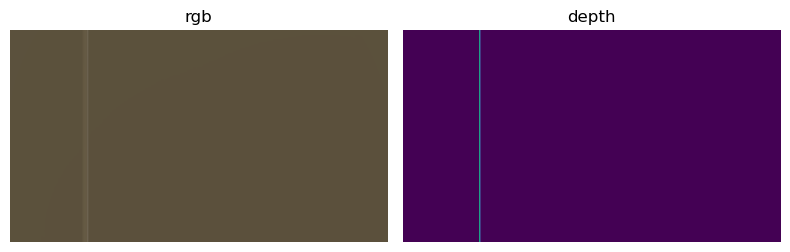

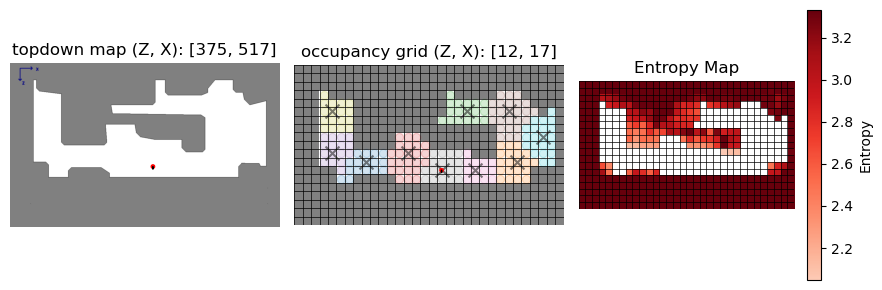



-->Likelihood vector:
 [ 7.5425e+73 2.0701e-132 2.7458e-108  1.2801e-92  5.5883e+65  6.7283e+48  1.2345e+11  8.4635e+30  9.2034e+77 7.7465e+107 1.1998e+105 3.4543e-260 1.5567e+169  2.7677e+38           0 2.6247e-125 1.2992e-139  4.9162e+20  2.8676e+21  2.2818e-51  5.8869e-78  8.5567e+67 2.7231e-254  1.8762e+63           0 3.0103e-191
           0]
Max likelihood:
 1.556663264093051e+169

Likelihood vector: [ 4.8453e-96 1.3299e-301 1.7639e-277 8.2233e-262 3.5899e-104 4.3223e-121 7.9306e-159 5.4369e-139  5.9123e-92  4.9763e-62  7.7075e-65           0           1 1.7779e-131           0 1.6861e-294 8.3458e-309 3.1582e-149 1.8422e-148 1.4658e-220 3.7817e-247 5.4968e-102           0 1.2053e-106           0           0
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 5.5582e-45 4.2616e-303 3.6501e-191 1.0662e-133  6.3518e-15   2.395e-28   1.345e-79 2.5963e-136   1.114e+76 1.1859e-136  1.7112e+59           0  3.4502e+51  4.1224e+38           0 3.2848e+171  9.5591e-88 1.4254e-156

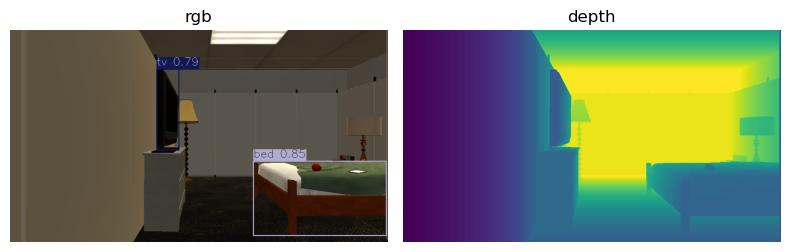

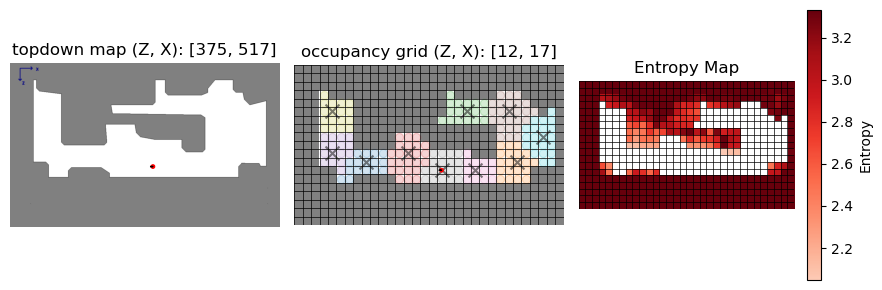



-->Likelihood vector:
 [7.2362e-131 4.7722e-294 5.5937e-140  1.6715e-69  3.0789e-39 4.2943e-102  6.1168e-59 1.4513e-182  1.3638e+83 2.7105e-233  9.5448e+39           0  1.4219e+17  6.0635e-13           0 3.0821e-184 2.9388e-148 7.8054e-169           0           0  4.2738e-90  2.1973e+13           0           0           0 5.2775e+177
           0]
Max likelihood:
 5.277528245429419e+177

Likelihood vector: [1.3711e-308           0 1.0599e-317 3.1673e-247 5.8339e-217 8.1369e-280  1.159e-236           0  2.5842e-95           0 1.8086e-138           0 2.6942e-161 1.1489e-190           0           0           0           0           0           0 8.0982e-268 4.1635e-165           0           0           0           1
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 2.1219e+85  2.7214e-39  1.305e-172   2.31e-121  1.4553e+28  3.1361e+19  5.6875e+16  7.7036e+10  1.1841e+77  5.481e-130  4.4776e+51 1.6789e+173  1.9477e+31  3.0385e+33           0 2.6997e-209 6.4015e-154  2.4281e+12

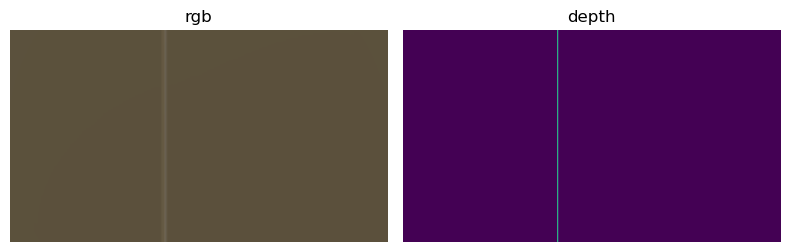

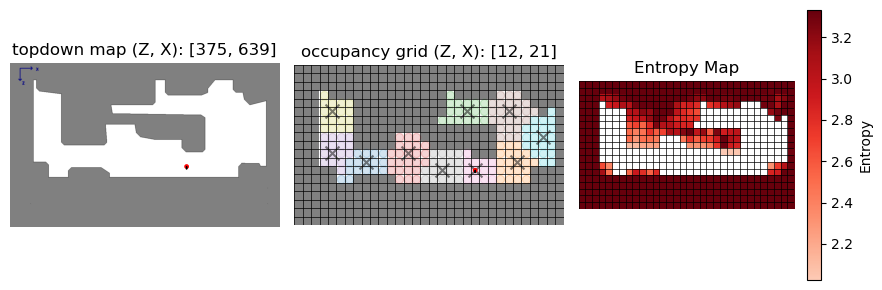



-->Likelihood vector:
 [ 4.9938e+82  3.9371e-35       22.77   1.165e+06  1.0968e+54  7.3687e+69  4.4049e+53  1.5799e+45  4.4495e+51 1.3644e+124  3.8242e+84  2.682e-117  4.2444e+40  8.3572e+72 5.4533e-251 3.9141e-147  5.2804e-56  5.4434e+20   1.444e+42  4.0307e-59   9.405e-83  1.7747e+63 1.1182e-215  6.1567e+63 2.3977e-257  4.9744e-73
 9.7887e-231]
Max likelihood:
 1.3643514236948784e+124

Likelihood vector: [ 3.6602e-42 2.8857e-159 1.6689e-123  8.539e-119  8.0391e-71  5.4009e-55  3.2286e-71   1.158e-79  3.2613e-73           1  2.8029e-40 1.9658e-241  3.1109e-84  6.1254e-52           0 2.8689e-271 3.8702e-180 3.9897e-104  1.0584e-82 2.9543e-183 6.8934e-207  1.3008e-61           0  4.5126e-61           0  3.646e-197
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [ 2.1822e-80           0 5.3249e-139 3.8468e-109  1.8471e+06  8.8165e-56  7.6944e-27 2.3184e-131  5.2481e+64 2.4535e+126 7.1296e+102 4.7649e-261  9.5955e+69  6.2883e+93 3.1216e-287  1.9697e+05      13.579 5.8223e-17

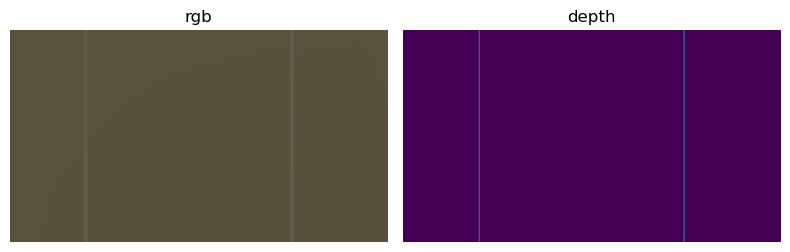

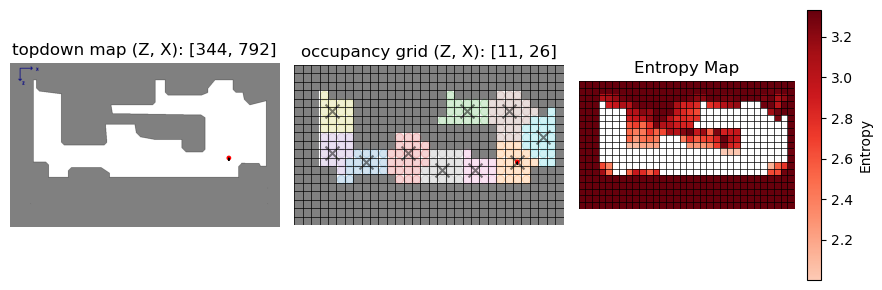



-->Likelihood vector:
 [ 1.1357e-50           0 9.5646e-283 5.9477e-210  2.7222e-47 4.6805e-171  2.1008e-46  1.563e-292 5.0109e+108 1.0862e-238  1.3738e+22           0  1.1899e+20  6.2738e-51           0 6.7831e-255 1.7653e-184 2.0281e-232           0           0  5.7664e-48  2.6122e-22           0           0           0 6.6647e-225
 1.0353e-226]
Max likelihood:
 5.010858935008495e+108

Likelihood vector: [2.2664e-159           0           0  1.187e-318 5.4325e-156 9.3408e-280 4.1926e-155           0           1           0  2.7415e-87           0  2.3746e-89  1.252e-159           0           0 3.5229e-293           0           0           0 1.1508e-156 5.2131e-131           0           0           0           0
           0]
Max likelihood: 1.0


-->Likelihood vector:
 [1.0286e-177           0           0 1.0885e-197 5.5787e-170 4.6154e-107 1.7841e-135 2.7728e-234  3.2214e+99 1.4471e-320  4.7898e+59 1.3626e-168  5.9473e+45 1.0125e-139           0 5.7717e+169  3.5708e-40 1.8105e-314

In [5]:
# Metrics init
target_found = False
num_actions = 0
travelled_distance = 0.0
closeness = float("inf")

# Simulation parameters
num_clusters = simtools.num_cluster_centers(num_free_cells, alpha=0.3, beta=0.5, max_clusters=num_free_cells)
w_e = 0.5  # Weight for entropy
w_d = 0.3  # Weight for distance
w_t = 0.2  # Weight for target probability (not used in this version)

# Main simulation loop
while (num_clusters <= num_free_cells) and (num_actions < MAX_ITER) and (not target_found):
    
    # Cluster grid map
    cluster_map = simtools.cluster_mapping(grid_free_cells, num_clusters)
    cluster_centers = simtools.get_cluster_centers(cluster_map, num_clusters)
    centroids = cluster_centers.copy() # For displaying logic

    # Assign each occ cell to a cluster center
    cluster_occ_cells_map = simtools.assign_cluster_centers_to_cells(grid_occ_cells, cluster_centers)

    # Entropy map
    entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

    # Display the simulation state
    simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)

    # Move into each cluster center
    while (cluster_centers) and (num_actions < MAX_ITER) and (not target_found):

        # Decide the cluster center to move to based on metric scores
        distances = []
        avg_entropies = []
        avg_target_probs = []

        # Computes scores for each cluster center
        for cluster_center in cluster_centers:
            
            # Compute path length to the cluster center
            distance, _ = simtools.compute_path(grid_position, cluster_center, grid_free_cells)
            distances.append(distance)

            # Compute the average entropy of the cluster
            avg_entropy = simtools.compute_average_entropy(belief_map, cluster_occ_cells_map[tuple(cluster_center)])
            avg_entropies.append(avg_entropy)

            # Compute the average target probability in the cluster
            avg_target_prob = simtools.compute_max_target_probability(belief_map, cluster_occ_cells_map[tuple(cluster_center)], indoor_objects.index(TARGET_OBJECT))
            avg_target_probs.append(avg_target_prob)

        # Print the scores 
        print(f"Cluster Centers: {cluster_centers}")
        print(f"Distances: {distances}")
        print(f"Avg Entropies: {avg_entropies}")
        print(f"Avg Target Probs: {avg_target_probs}")

        # Normalizze entropies and distances
        distances = np.array(distances)
        avg_entropies = np.array(avg_entropies)
        avg_target_probs = np.array(avg_target_probs)
        avg_entropies = avg_entropies / MAX_ENTROPY
        distances = distances / max(distances)

        # Compute the weighted score for each cluster center
        scores = w_e * avg_entropies + w_d * (1-distances) + w_t * avg_target_probs

        # Compute the maximum score index
        max_score_idx = np.argmax(scores)

        # Get the cluster center with the maximum score
        cluster_center = cluster_centers[max_score_idx]

        # Get the path to the cluster center
        _, path = simtools.compute_path(grid_position, cluster_center, grid_free_cells)
        print(f"Moving to cluster center: {cluster_center} with path length: {len(path)}")
        print(f"Path: {path}")

        # Print the normalized scores
        print(f"Normalized Entropies: {avg_entropies}")
        print(f"Normalized Distances: {distances}")
        print(f"Scores: {scores}")

        # Move through the path
        while (path) and (num_actions < MAX_ITER) and (not target_found):
            
            # Optimal orientation to face the cluster center
            facing_yaw = simtools.compute_facing_rotation(grid_position, path[-1])
            action = simtools.compute_rotation_action(agent_yaw, facing_yaw)

            # Perform the rotation action, if needed
            if action:
                grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
                agent_quart = myutils.yaw_to_quaternion(agent_yaw)
                agent_state.rotation = agent_quart
                agent.set_state(agent_state)

                # Update metrics
                num_actions += 1
                
                # Get observations
                observations = sim.get_sensor_observations(0)
                rgb = observations["color_sensor"]
                depth = observations["depth_sensor"]

                # YOLO Prediction
                results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
                detections = simtools.parse_yolo_detections(results)
                simtools.merge_rgb_yolo_outputs(rgb, detections)
                target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)
                
                # Initialize processed cells
                processed_cells = []

                # Process the observations
                for det in detections:
                    box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                    scale = myutils.compute_bbox_scale(box, rgb)

                    # Center of bbox and depth value
                    center_x, center_y = simtools.get_box_center(box)
                    depth_value = depth[center_y, center_x]

                    # Project to real world, grid and map coords
                    camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                    object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                    object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                    # Check if projected cell is outside free grid cells
                    if object_grid_position in grid_free_cells:
                        object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                    # Add this cell to processed cells
                    if tuple(object_grid_position) not in processed_cells:
                        processed_cells.append(tuple(object_grid_position))

                    # Likelihood vector: likelihood of each class (Rule 1)
                    likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                    # Kaplan Update to the belief map in that cell
                    grid_x, grid_y = object_grid_position
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Compute every theoretically visible occupied cell
                rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
                visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)
               
                # Go through every visible occupied cell and update the belief map
                for cell in visible_occ_cells:
                    if tuple(cell) not in processed_cells:

                        # Compute distance to the cell
                        grid_x, grid_y = cell
                        distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                        # Compute the likelihood vector for the cell (Rule 2)
                        likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                        # Kaplan update to the belief map in that cell
                        belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

                # Entropy map
                entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

                # Display the simulation state 
                if (num_actions % DISPLAY_STEP == 0):
                    simtools.display_sim_observations(rgb, depth)
                    simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)

            # Check if target was found
            if target_found: break

            # Move action to next path cell 
            action = simtools.compute_relative_move_action(grid_position, path[0], agent_yaw)
            grid_position, agent_yaw = simtools.perform_action(action, grid_position, agent_yaw)
            idx = grid_free_cells.index(grid_position)
            map_position, world_position = map_free_cells[idx], world_free_coords[idx]
            agent_positions = (map_position, grid_position)
            agent_state.position = world_position
            agent.set_state(agent_state)

            # Update metrics
            travelled_distance += CELL_SIDE
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            detections = simtools.parse_yolo_detections(results)
            simtools.merge_rgb_yolo_outputs(rgb, detections)
            target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

            # Initialize processed cells
            processed_cells = []

            # Process the observations
            for det in detections:
                box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                scale = myutils.compute_bbox_scale(box, rgb)

                # Center of bbox and depth value
                center_x, center_y = simtools.get_box_center(box)
                depth_value = depth[center_y, center_x]

                # Project to real world, grid and map coords
                camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                # Check if projected cell is outside free grid cells
                if object_grid_position in grid_free_cells:
                    object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                # Add this cell to processed cells
                if tuple(object_grid_position) not in processed_cells:
                    processed_cells.append(tuple(object_grid_position))

                # Likelihood vector: likelihood of each class (Rule 1)
                likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                # Kaplan Update to the belief map in that cell
                grid_x, grid_y = object_grid_position
                belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

            # Compute every theoretically visible occupied cell
            rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
            visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)

            # Go through every visible occupied cell and update the belief map
            for cell in visible_occ_cells:
                if tuple(cell) not in processed_cells:

                    # Compute distance to the cell
                    grid_x, grid_y = cell
                    distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                    # Compute the likelihood vector for the cell (Rule 2)
                    likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                    # Kaplan update to the belief map in that cell
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

            # Entropy map
            entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

            # Display the simulation state 
            if (num_actions % DISPLAY_STEP == 0):
                simtools.display_sim_observations(rgb, depth)
                simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)
        
            # Remove the path cell
            path.pop(0)

        # Check if target was found
        if target_found: break

        # When in cluster center, rotate 3 times to get the full 360 degrees view
        for i in range(3):
            grid_position, agent_yaw = simtools.perform_action('turn_right', grid_position, agent_yaw)
            agent_quart = myutils.yaw_to_quaternion(agent_yaw)
            agent_state.rotation = agent_quart
            agent.set_state(agent_state)

            # Update metrics
            num_actions += 1

            # Get observations
            observations = sim.get_sensor_observations(0)
            rgb = observations["color_sensor"]
            depth = observations["depth_sensor"]

            # YOLO Prediction
            results = yolo_model.predict(source=rgb[:,:,:3], device='cuda:0', conf=0.30, iou=0.40, verbose=False, max_det=10)
            detections = simtools.parse_yolo_detections(results)
            simtools.merge_rgb_yolo_outputs(rgb, detections)
            target_found, target_bbox = simtools.was_target_found(TARGET_OBJECT_ID, detections, CONFIDENCE_THRESHOLD)

            # Initialize processed cells
            processed_cells = []

            # Process the observations
            for det in detections:
                box, class_id, confidence, name, prob_vector = itemgetter('box', 'class_id', 'confidence', 'name', 'prob_vector')(det)
                scale = myutils.compute_bbox_scale(box, rgb)

                # Center of bbox and depth value
                center_x, center_y = simtools.get_box_center(box)
                depth_value = depth[center_y, center_x]

                # Project to real world, grid and map coords
                camera_world_position = simtools.get_camera_pos_from_agent_pos(world_position, AGENT_HEIGHT)
                object_position = simtools.compute_real_world_position_from_pixel(camera_world_position, agent_quart, depth_value, center_x, center_y, intrinsics)
                object_map_position, object_grid_position = simtools.get_2d_coords(object_position, topdown_resolution, grid_resolution, sim.pathfinder)

                # Check if projected cell is outside free grid cells
                if object_grid_position in grid_free_cells:
                    object_grid_position = simtools.get_closest_grey_cell(tuple(object_grid_position), grid_map)

                # Add this cell to processed cells
                if tuple(object_grid_position) not in processed_cells:
                    processed_cells.append(tuple(object_grid_position))

                # Likelihood vector: likelihood of each class (Rule 1)
                likelihood_vector = probtools.compute_likelihood_vector(prob_vector, scale, dirichlet_priors, classes_bins)

                # Kaplan Update to the belief map in that cell
                grid_x, grid_y = object_grid_position
                belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

            # Compute every theoretically visible occupied cell
            rays = simtools.simulate_visibility_rays(grid_map, grid_position, agent_yaw)
            visible_occ_cells = simtools.compute_visible_occ_cells(rays, grid_map, depth, grid_cells, world_coords, grid_position, agent_state.rotation, intrinsics)

            # Go through every visible occupied cell and update the belief map
            for cell in visible_occ_cells:
                if tuple(cell) not in processed_cells:

                    # Compute distance to the cell
                    grid_x, grid_y = cell
                    distance = np.linalg.norm((np.array(grid_position) - np.array([grid_x, grid_y]))* CELL_SIDE)

                    # Compute the likelihood vector for the cell (Rule 2)
                    likelihood_vector = probtools.compute_background_likelihood_vector(distance, NUM_CLASSES)

                    # Kaplan update to the belief map in that cell
                    belief_map[grid_x][grid_y] = probtools.kaplan_update(belief_map[grid_x][grid_y], likelihood_vector)

            # Entropy map
            entropy_map = simtools.compute_entropy_map(belief_map, grid_map)

            # Display the simulation state 
            if (i % DISPLAY_STEP == 0):
                simtools.display_sim_observations(rgb, depth)
                simtools.display_topdown_and_entropy_maps(topdown_map, grid_map, entropy_map, cluster_map, centroids, agent_positions, agent_radius, agent_yaw)

            # Check if target was found
            if target_found: break 

        # Remove cluster center
        cluster_centers.remove(cluster_center)

    # Double the number of clusters if all clusters were visited
    num_clusters *= 2


Target object <teddy bear> found after 379 actions!
Found location: [    -11.476   -0.016193      10.597]
Real location: [-11.4488227345562, 0.8050001102812845, 10.671119840569014]


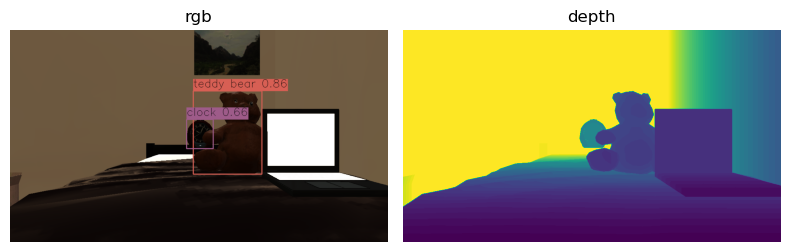

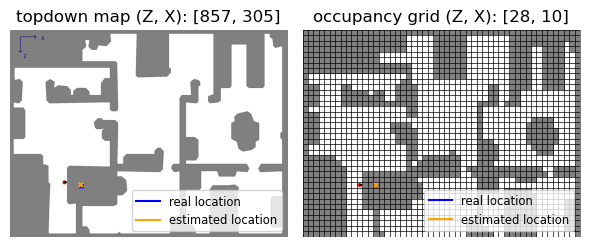

Number of actions: 379
Travelled distance: 92.40 m
Computed localization error: 0.079 m


In [7]:
# Target found or not
if target_found:
    # Real world position 
    center_x, center_y = simtools.get_box_center(target_bbox)
    depth_value = depth[center_y, center_x]
    target_object_position = simtools.compute_real_world_position_from_pixel(agent_state.position, agent_state.rotation, depth_value, center_x, center_y, intrinsics)

    # Closeness to the target location
    closeness = simtools.compute_closeness(target_object_position, REAL_TARGET_LOCATION)

    # Convert to 2D coordinates
    target_map_position, target_grid_position = simtools.get_2d_coords(target_object_position, topdown_resolution, grid_resolution, sim.pathfinder)
    target_real_map_position, target_real_grid_position = simtools.get_2d_coords(REAL_TARGET_LOCATION, topdown_resolution, grid_resolution, sim.pathfinder)
    target_2d_coords = (target_map_position, target_grid_position)
    target_real_2d_coords = (target_real_map_position, target_real_grid_position)
    target_coords = (target_real_2d_coords, target_2d_coords)

    # Show info
    print(f"\nTarget object <{TARGET_OBJECT}> found after {num_actions} actions!")
    print(f"Found location: {target_object_position}")
    print(f"Real location: {REAL_TARGET_LOCATION}")
    simtools.display_sim_observations(rgb, depth)
    simtools.display_topdown_maps_with_target(topdown_map, grid_map, agent_positions, agent_radius, agent_yaw, target_coords)
else:
    print(f"\nTarget object <{TARGET_OBJECT}> not found after {MAX_ITER} actions!")
    print(f"Real location: {REAL_TARGET_LOCATION}")

# Display simulation metrics
print(f"Number of actions: {num_actions}")
print(f"Travelled distance: {travelled_distance:.2f} m")
print(f"Computed localization error: {closeness:.3f} m")